In [1]:
import os
import cv2
import random
import shutil
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

from glob import glob
from pathlib import Path

from sklearn.model_selection import train_test_split

import albumentations as A

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F 

import warnings
warnings.filterwarnings("ignore")

In [2]:
# ============================================================
# Configuration
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -----------------------------

DATASET_PATH = r"C:\Users\HP\Desktop\GAVE2_preliminary\training"

IMAGE_FOLDER = os.path.join(DATASET_PATH, "images")
GT_FOLDER = os.path.join(DATASET_PATH, "av")
ROI_FOLDER = os.path.join(DATASET_PATH, "masks")

# -----------------------------

OUTPUT_DIR = "./Processed_Dataset"

TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

IMAGE_SIZE = 768

BATCH_SIZE = 2

NUM_CLASSES = 4

EPOCHS = 75

LR = 1e-4

WEIGHT_DECAY = 1e-4

NUM_WORKERS = 0

PIN_MEMORY = True

print("Device :", DEVICE)

Device : cuda


In [ ]:
# ============================================================
# Folder Structure
# ============================================================

folders = [

    "train/images",
    "train/av",

    "val/images",
    "val/av",

    "test/images",
    "test/av"

]

if os.path.exists(OUTPUT_DIR):
    shutil.rmtree(OUTPUT_DIR)

for folder in folders:

    os.makedirs(os.path.join(OUTPUT_DIR, folder), exist_ok=True)

print("Folder structure created.")

Folder structure created.


In [4]:
# ============================================================
# Collect Images
# ============================================================

image_paths = sorted(glob(os.path.join(IMAGE_FOLDER, "*")))
gt_paths = sorted(glob(os.path.join(GT_FOLDER, "*")))
roi_paths = sorted(glob(os.path.join(ROI_FOLDER, "*")))

assert len(image_paths) == len(gt_paths) == len(roi_paths), \
    "Mismatch in number of images, AV masks, and ROI masks."

print(f"Total Images : {len(image_paths)}")

Total Images : 50


In [5]:
# ============================================================
# Train / Validation / Test Split
# ============================================================

train_images, temp_images, train_gt, temp_gt, train_roi, temp_roi = train_test_split(

    image_paths,
    gt_paths,
    roi_paths,

    test_size=0.30,

    random_state=SEED,

    shuffle=True

)

val_images, test_images, val_gt, test_gt, val_roi, test_roi = train_test_split(

    temp_images,
    temp_gt,
    temp_roi,

    test_size=0.50,

    random_state=SEED,

    shuffle=True

)

print(f"Train      : {len(train_images)}")
print(f"Validation : {len(val_images)}")
print(f"Test       : {len(test_images)}")

Train      : 35
Validation : 7
Test       : 8


In [6]:
def copy_files(images, gts, rois, split):

    image_out = os.path.join(OUTPUT_DIR, split, "images")
    gt_out = os.path.join(OUTPUT_DIR, split, "av")
    roi_out = os.path.join(OUTPUT_DIR, split, "masks")

    os.makedirs(gt_out, exist_ok=True)
    os.makedirs(roi_out, exist_ok=True)

    for img, gt, roi in zip(images, gts, rois):

        shutil.copy(img, image_out)
        shutil.copy(gt, gt_out)
        shutil.copy(roi, roi_out)
        
train_images, temp_images, train_gt, temp_gt, train_roi, temp_roi = train_test_split(
    image_paths,
    gt_paths,
    roi_paths,
    test_size=0.30,
    random_state=SEED,
    shuffle=True
)

val_images, test_images, val_gt, test_gt, val_roi, test_roi = train_test_split(
    temp_images,
    temp_gt,
    temp_roi,
    test_size=0.50,
    random_state=SEED,
    shuffle=True
)

copy_files(train_images, train_gt, train_roi, "train")
copy_files(val_images, val_gt, val_roi, "val")
copy_files(test_images, test_gt, test_roi, "test")

In [7]:
# ============================================================
# Create Processed Dataset Folders
# ============================================================

PROCESSED_DIR = "./Preprocessed_Dataset"

folders = [
    "train/images",
    "train/av",
    "train/masks",

    "val/images",
    "val/av",
    "val/masks",

    "test/images",
    "test/av",
    "test/masks"
]

if os.path.exists(PROCESSED_DIR):
    shutil.rmtree(PROCESSED_DIR)

for folder in folders:
    os.makedirs(os.path.join(PROCESSED_DIR, folder), exist_ok=True)

print("Processed dataset folders created.")

Processed dataset folders created.


In [8]:
# ============================================================
# Preprocessing Helper Functions
# ============================================================

def apply_roi(image, roi):
    """
    Keep only retinal region.
    """

    roi = (roi > 0).astype(np.uint8)

    return cv2.bitwise_and(image, image, mask=roi)


def extract_green(image):
    """
    Extract green channel.
    """

    return image[:, :, 1]


def apply_clahe(green):

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )

    return clahe.apply(green)


def pad_to_square(image, pad_value=0):

    h, w = image.shape[:2]

    size = max(h, w)

    top = (size - h) // 2
    bottom = size - h - top

    left = (size - w) // 2
    right = size - w - left

    if len(image.shape) == 2:

        return cv2.copyMakeBorder(
            image,
            top,
            bottom,
            left,
            right,
            cv2.BORDER_CONSTANT,
            value=pad_value
        )

    return cv2.copyMakeBorder(
        image,
        top,
        bottom,
        left,
        right,
        cv2.BORDER_CONSTANT,
        value=(pad_value, pad_value, pad_value)
    )


def resize_image(image, interpolation):

    return cv2.resize(
        image,
        (IMAGE_SIZE, IMAGE_SIZE),
        interpolation=interpolation
    )

In [9]:
# ============================================================
# RGB Mask to Class Mask
# ============================================================

def rgb_to_class(mask):

    label = np.zeros(mask.shape[:2], dtype=np.uint8)

    # Background
    label[np.all(mask == [0, 0, 0], axis=-1)] = 0

    # Artery (Red)
    label[np.all(mask == [255, 0, 0], axis=-1)] = 1

    # Overlap (Green)
    label[np.all(mask == [0, 255, 0], axis=-1)] = 2

    # Vein (Blue)
    label[np.all(mask == [0, 0, 255], axis=-1)] = 3

    return label

In [10]:
# ============================================================
# Preprocess One Sample
# ============================================================

def preprocess_sample(image_path, roi_path, gt_path):

    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    roi = cv2.imread(roi_path, 0)

    gt = cv2.imread(gt_path)
    gt = cv2.cvtColor(gt, cv2.COLOR_BGR2RGB)

    image = apply_roi(image, roi)

    image = extract_green(image)

    image = apply_clahe(image)

    image = pad_to_square(image)

    image = resize_image(
        image,
        cv2.INTER_LINEAR
    )

    gt = rgb_to_class(gt)

    gt = pad_to_square(gt)

    gt = resize_image(
        gt,
        cv2.INTER_NEAREST
    )

    roi = pad_to_square(roi)

    roi = resize_image(
        roi,
        cv2.INTER_NEAREST
    )

    return image, gt, roi

In [11]:
# ============================================================
# Process Dataset
# ============================================================

splits = ["train", "val", "test"]

for split in splits:

    image_dir = os.path.join(OUTPUT_DIR, split, "images")
    gt_dir = os.path.join(OUTPUT_DIR, split, "av")
    roi_dir = os.path.join(OUTPUT_DIR, split, "masks")

    out_img = os.path.join(PROCESSED_DIR, split, "images")
    out_gt = os.path.join(PROCESSED_DIR, split, "av")
    out_roi = os.path.join(PROCESSED_DIR, split, "masks")

    images = sorted(glob(os.path.join(image_dir, "*")))
    gts = sorted(glob(os.path.join(gt_dir, "*")))
    rois = sorted(glob(os.path.join(roi_dir, "*")))

    for img_path, gt_path, roi_path in tqdm(
        zip(images, gts, rois),
        total=len(images),
        desc=split
    ):

        image, gt, roi = preprocess_sample(
            img_path,
            roi_path,
            gt_path
        )

        name = os.path.basename(img_path)

        cv2.imwrite(
            os.path.join(out_img, name),
            image
        )

        cv2.imwrite(
            os.path.join(out_gt, name),
            gt
        )

        cv2.imwrite(
            os.path.join(out_roi, name),
            roi
        )

print("Preprocessing completed.")

test: 100%|██████████| 8/8 [00:00<00:00,  8.32it/s]

Preprocessing completed.


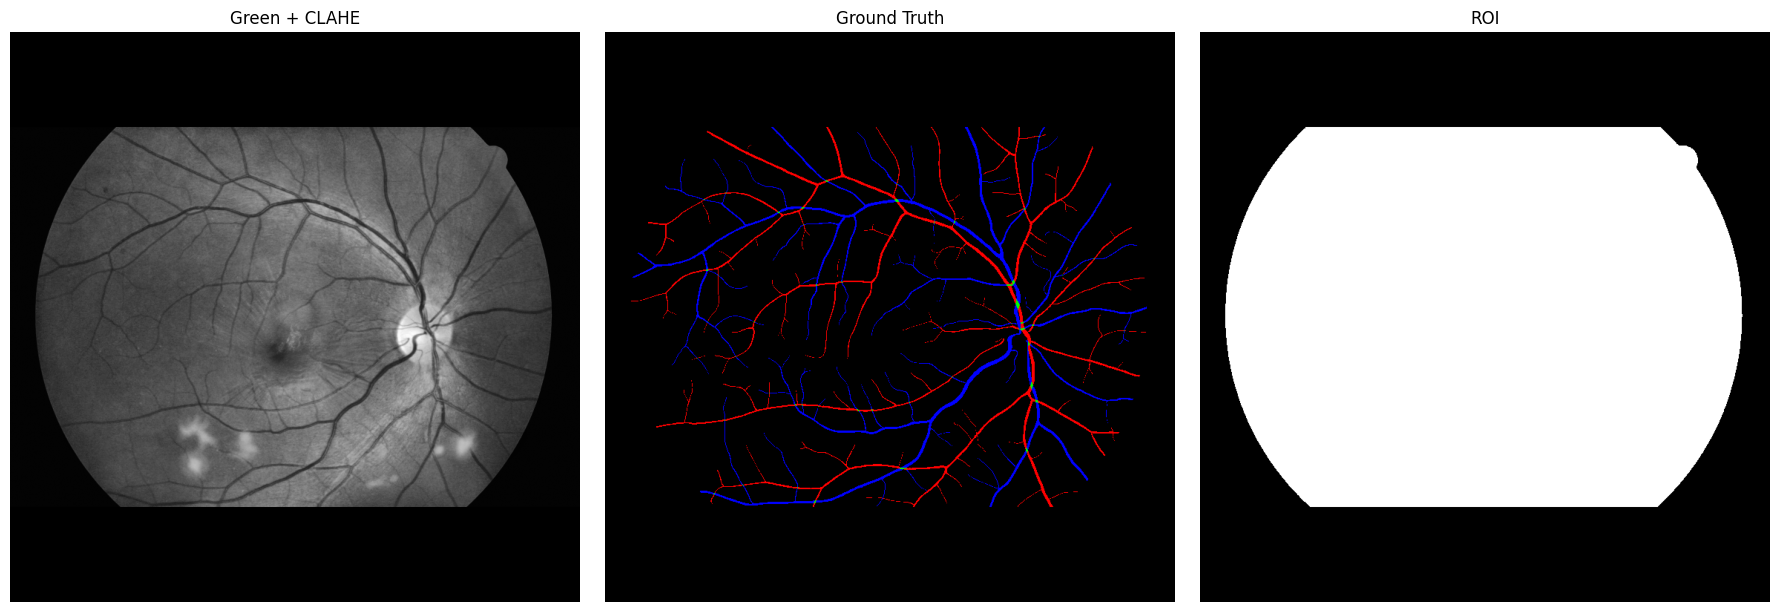

In [12]:
# ============================================================
# Visual Verification
# ============================================================

def class_to_rgb(mask):
    """
    Convert class mask back to RGB for visualization only.
    """

    rgb = np.zeros((mask.shape[0], mask.shape[1], 3), dtype=np.uint8)

    rgb[mask == 0] = [0, 0, 0]         # Background
    rgb[mask == 1] = [255, 0, 0]       # Artery
    rgb[mask == 2] = [0, 255, 0]       # Overlap
    rgb[mask == 3] = [0, 0, 255]       # Vein

    return rgb


sample = sorted(glob(os.path.join(PROCESSED_DIR, "train/images/*")))[0]

name = os.path.basename(sample)

image = cv2.imread(sample, cv2.IMREAD_GRAYSCALE)

gt = cv2.imread(
    os.path.join(PROCESSED_DIR, "train/av", name),
    cv2.IMREAD_GRAYSCALE
)

roi = cv2.imread(
    os.path.join(PROCESSED_DIR, "train/masks", name),
    cv2.IMREAD_GRAYSCALE
)

gt_rgb = class_to_rgb(gt)

plt.figure(figsize=(18,6))

plt.subplot(131)
plt.imshow(image, cmap="gray")
plt.title("Green + CLAHE")
plt.axis("off")

plt.subplot(132)
plt.imshow(gt_rgb)
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(133)
plt.imshow(roi, cmap="gray")
plt.title("ROI")
plt.axis("off")

plt.tight_layout()
plt.show()

In [13]:
# ============================================================
# Generate Distance Maps
# ============================================================

from scipy.ndimage import distance_transform_edt

DISTANCE_DIR = "./Distance_Maps"

if os.path.exists(DISTANCE_DIR):
    shutil.rmtree(DISTANCE_DIR)

for split in ["train", "val", "test"]:

    os.makedirs(
        os.path.join(DISTANCE_DIR, split),
        exist_ok=True
    )

    masks = sorted(
        glob(os.path.join(PROCESSED_DIR, split, "av", "*"))
    )

    for mask_path in tqdm(masks, desc=split):

        mask = cv2.imread(
            mask_path,
            cv2.IMREAD_GRAYSCALE
        )

        vessel = (mask > 0).astype(np.uint8)

        inside = distance_transform_edt(vessel)

        outside = distance_transform_edt(1 - vessel)

        dist = inside + outside

        dist = dist.astype(np.float32)

        dist = np.exp(-dist / 8.0).astype(np.float32)

        np.save(

            os.path.join(

                DISTANCE_DIR,
                split,
                Path(mask_path).stem + ".npy"

            ),

            dist

        )

print("Distance maps created.")

test: 100%|██████████| 8/8 [00:00<00:00, 14.97it/s]

Distance maps created.


In [14]:
# ============================================================
# Create Augmented Dataset
# ============================================================

AUGMENTED_DIR = "./Augmented_Dataset"

folders = [

    "train/images",
    "train/av",
    "train/masks",
    "train/distance",

    "val/images",
    "val/av",
    "val/masks",
    "val/distance",

    "test/images",
    "test/av",
    "test/masks",
    "test/distance"

]

if os.path.exists(AUGMENTED_DIR):
    shutil.rmtree(AUGMENTED_DIR)

for folder in folders:
    os.makedirs(
        os.path.join(AUGMENTED_DIR, folder),
        exist_ok=True
    )

print("Augmented dataset folders created.")

Augmented dataset folders created.


In [15]:
# ============================================================
# Copy Validation and Test Sets
# ============================================================

for split in ["val", "test"]:

    # Images
    src = os.path.join(PROCESSED_DIR, split, "images")
    dst = os.path.join(AUGMENTED_DIR, split, "images")

    for file in os.listdir(src):

        shutil.copy(
            os.path.join(src, file),
            os.path.join(dst, file)
        )

    # Ground Truth
    src = os.path.join(PROCESSED_DIR, split, "av")
    dst = os.path.join(AUGMENTED_DIR, split, "av")

    for file in os.listdir(src):

        shutil.copy(
            os.path.join(src, file),
            os.path.join(dst, file)
        )

    # ROI
    src = os.path.join(PROCESSED_DIR, split, "masks")
    dst = os.path.join(AUGMENTED_DIR, split, "masks")

    for file in os.listdir(src):

        shutil.copy(
            os.path.join(src, file),
            os.path.join(dst, file)
        )

    # Distance Maps
    src = os.path.join(DISTANCE_DIR, split)
    dst = os.path.join(AUGMENTED_DIR, split, "distance")

    for file in os.listdir(src):

        shutil.copy(
            os.path.join(src, file),
            os.path.join(dst, file)
        )

print("Validation and Test copied successfully.")

Validation and Test copied successfully.


In [16]:
# ============================================================
# Offline Augmentations
# ============================================================

augmentations = {

    "hflip":
    A.HorizontalFlip(p=1),

    "vflip":
    A.VerticalFlip(p=1),

    "rot_p15":
    A.Rotate(
        limit=(15,15),
        border_mode=cv2.BORDER_CONSTANT,
        p=1
    ),

    "rot_m15":
    A.Rotate(
        limit=(-15,-15),
        border_mode=cv2.BORDER_CONSTANT,
        p=1
    ),

    "brightness":
    A.RandomBrightnessContrast(
        brightness_limit=0.15,
        contrast_limit=0.15,
        p=1
    ),

    "gamma":
    A.RandomGamma(
        gamma_limit=(80,120),
        p=1
    ),

    "elastic":
    A.ElasticTransform(
        alpha=20,
        sigma=4,
        interpolation=cv2.INTER_LINEAR,
        border_mode=cv2.BORDER_CONSTANT,
        p=1
    ),

    "affine":
    A.Affine(
        scale=(0.95, 1.05),
        translate_percent=(-0.05, 0.05),
        rotate=(-10, 10),
        interpolation=cv2.INTER_LINEAR,
        mask_interpolation=cv2.INTER_NEAREST,
        cval=0,
        p=1
    )

}

In [17]:
# ============================================================
# Copy Original Training Set
# ============================================================

for folder in ["images", "av", "masks"]:

    src = os.path.join(PROCESSED_DIR, "train", folder)
    dst = os.path.join(AUGMENTED_DIR, "train", folder)

    for file in os.listdir(src):

        shutil.copy(
            os.path.join(src, file),
            os.path.join(dst, file)
        )

print("Original training images copied.")

Original training images copied.


In [18]:
# ============================================================
# Offline Augmentation (Image + GT + ROI + Distance Map)
# ============================================================

train_images = sorted(glob(os.path.join(PROCESSED_DIR, "train/images/*")))
train_gt = sorted(glob(os.path.join(PROCESSED_DIR, "train/av/*")))
train_roi = sorted(glob(os.path.join(PROCESSED_DIR, "train/masks/*")))
train_dist = sorted(glob(os.path.join(DISTANCE_DIR, "train/*.npy")))

# Create output folder
os.makedirs(os.path.join(AUGMENTED_DIR, "train/distance"), exist_ok=True)

# Copy original distance maps
for dist in train_dist:

    shutil.copy(
        dist,
        os.path.join(
            AUGMENTED_DIR,
            "train/distance",
            os.path.basename(dist)
        )
    )

for img_path, gt_path, roi_path, dist_path in tqdm(

    zip(train_images, train_gt, train_roi, train_dist),

    total=len(train_images)

):

    image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    gt = cv2.imread(gt_path, cv2.IMREAD_GRAYSCALE)

    roi = cv2.imread(roi_path, cv2.IMREAD_GRAYSCALE)

    dist = np.load(dist_path)

    base = Path(img_path).stem

    for aug_name, aug in augmentations.items():

        if aug_name in ["brightness", "gamma"]:

            aug_image = aug(image=image)["image"]

            aug_gt = gt.copy()

            aug_roi = roi.copy()

            aug_dist = dist.copy()

        else:

            augmented = aug(

                image=image,

                mask=gt,

                masks=[roi, dist]

            )

            aug_image = augmented["image"]

            aug_gt = augmented["mask"]

            aug_roi = augmented["masks"][0]

            aug_dist = augmented["masks"][1]

        filename = f"{base}_{aug_name}"

        cv2.imwrite(
            os.path.join(
                AUGMENTED_DIR,
                "train/images",
                filename + ".png"
            ),
            aug_image
        )

        cv2.imwrite(
            os.path.join(
                AUGMENTED_DIR,
                "train/av",
                filename + ".png"
            ),
            aug_gt
        )

        cv2.imwrite(
            os.path.join(
                AUGMENTED_DIR,
                "train/masks",
                filename + ".png"
            ),
            aug_roi
        )

        np.save(

            os.path.join(
                AUGMENTED_DIR,
                "train/distance",
                filename + ".npy"
            ),

            aug_dist.astype(np.float32)

        )

print("Offline augmentation completed.")

100%|██████████| 35/35 [00:11<00:00,  3.10it/s]

Offline augmentation completed.


In [19]:
# ============================================================
# Dataset Statistics
# ============================================================

for split in ["train", "val", "test"]:

    n = len(glob(os.path.join(AUGMENTED_DIR, split, "images/*")))

    print(f"{split:5s} : {n}")

train : 315
val   : 7
test  : 8


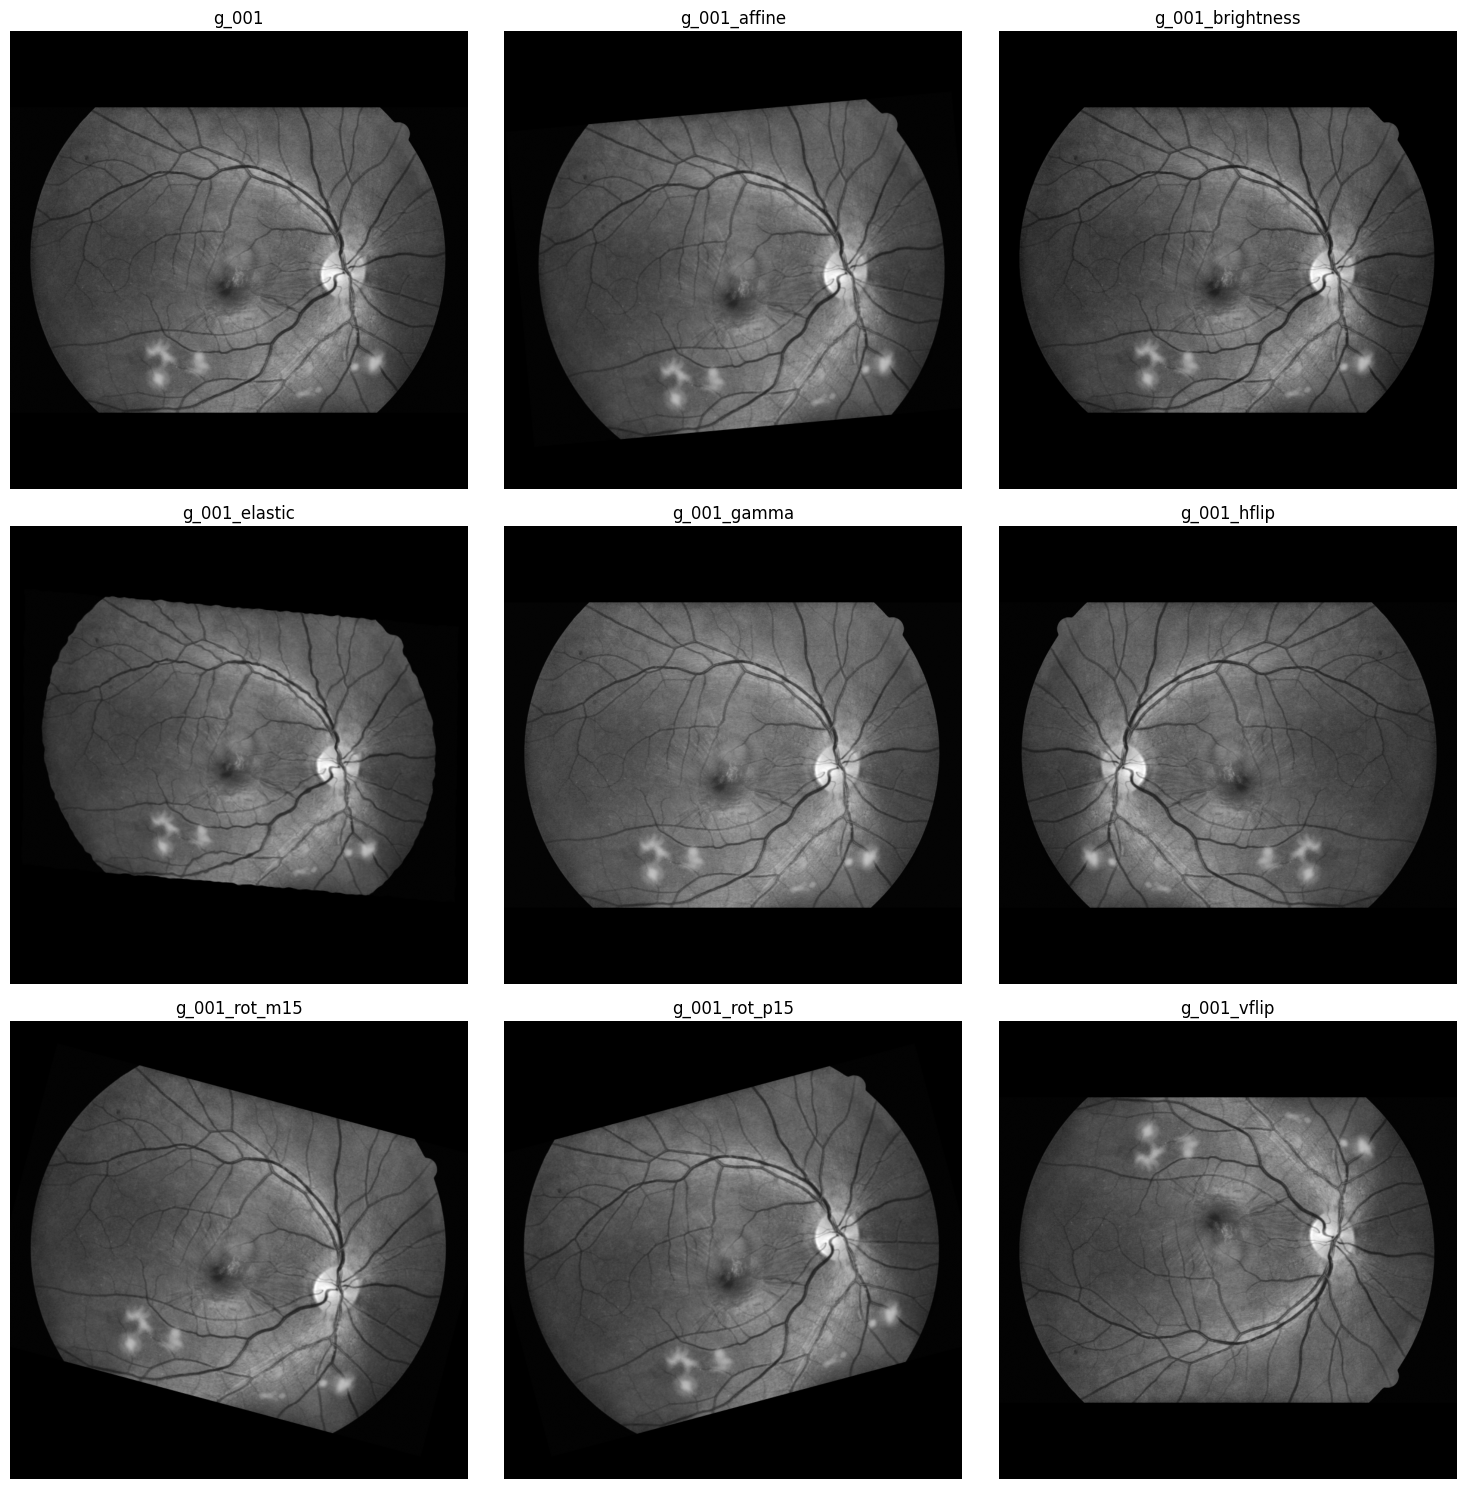

In [20]:
# ============================================================
# Visualize Augmentations
# ============================================================

samples = sorted(glob(os.path.join(AUGMENTED_DIR, "train/images/*")))[:9]

plt.figure(figsize=(15,15))

for i, sample in enumerate(samples):

    img = cv2.imread(sample, cv2.IMREAD_GRAYSCALE)

    plt.subplot(3,3,i+1)

    plt.imshow(img, cmap="gray")

    plt.title(Path(sample).stem)

    plt.axis("off")

plt.tight_layout()

plt.show()

In [21]:
# ============================================================
# Dataset Class
# ============================================================

class RetinalDataset(Dataset):

    def __init__(self, image_dir, mask_dir, distance_dir):

        self.images = sorted(glob(os.path.join(image_dir, "*")))
        self.masks = sorted(glob(os.path.join(mask_dir, "*")))
        self.distance = sorted(glob(os.path.join(distance_dir, "*.npy")))

        assert len(self.images) == len(self.masks) == len(self.distance)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        image = cv2.imread(
            self.images[idx],
            cv2.IMREAD_GRAYSCALE
        ).astype(np.float32) / 255.0

        image = np.expand_dims(image, axis=0)

        mask = cv2.imread(
            self.masks[idx],
            cv2.IMREAD_GRAYSCALE
        )

        distance = np.load(self.distance[idx]).astype(np.float32)

        distance = np.expand_dims(distance, axis=0)

        image = torch.from_numpy(image).float()
        mask = torch.from_numpy(mask).long()
        distance = torch.from_numpy(distance).float()

        return image, mask, distance

In [22]:
# ============================================================
# DataLoaders
# ============================================================

train_dataset = RetinalDataset(

    os.path.join(AUGMENTED_DIR, "train/images"),
    os.path.join(AUGMENTED_DIR, "train/av"),
    os.path.join(AUGMENTED_DIR, "train/distance")

)

val_dataset = RetinalDataset(

    os.path.join(AUGMENTED_DIR, "val/images"),
    os.path.join(AUGMENTED_DIR, "val/av"),
    os.path.join(AUGMENTED_DIR, "val/distance")

)

test_dataset = RetinalDataset(

    os.path.join(AUGMENTED_DIR, "test/images"),
    os.path.join(AUGMENTED_DIR, "test/av"),
    os.path.join(AUGMENTED_DIR, "test/distance")

)

train_loader = DataLoader(

    train_dataset,

    batch_size=BATCH_SIZE,

    shuffle=True,

    num_workers=NUM_WORKERS,

    pin_memory=PIN_MEMORY

)

val_loader = DataLoader(

    val_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=NUM_WORKERS,

    pin_memory=PIN_MEMORY

)

test_loader = DataLoader(

    test_dataset,

    batch_size=1,

    shuffle=False,

    num_workers=NUM_WORKERS,

    pin_memory=PIN_MEMORY

)

print("Train :", len(train_dataset))
print("Validation :", len(val_dataset))
print("Test :", len(test_dataset))

Train : 315
Validation : 7
Test : 8


In [23]:
# ============================================================
# Verify Dataset
# ============================================================

images, masks, distance = next(iter(train_loader))

print(images.shape)
print(masks.shape)
print(distance.shape)

print(torch.unique(masks))

torch.Size([2, 1, 768, 768])
torch.Size([2, 768, 768])
torch.Size([2, 1, 768, 768])
tensor([0, 1, 2, 3])


In [24]:
# ============================================================
# Double Convolution Block
# ============================================================

class DoubleConv(nn.Module):

    def __init__(self, in_channels, out_channels):

        super().__init__()

        self.conv = nn.Sequential(

            nn.Conv2d(in_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)

        )

    def forward(self, x):

        return self.conv(x)

In [25]:
# ============================================================
# Attention Gate
# ============================================================

class AttentionBlock(nn.Module):

    def __init__(self, F_g, F_l, F_int):

        super().__init__()

        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, kernel_size=1, bias=True),
            nn.BatchNorm2d(F_int)
        )

        self.W_x = nn.Sequential(
            nn.Conv2d(F_l, F_int, kernel_size=1, bias=True),
            nn.BatchNorm2d(F_int)
        )

        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, kernel_size=1, bias=True),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )

        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):

        g1 = self.W_g(g)

        x1 = self.W_x(x)

        psi = self.relu(g1 + x1)

        psi = self.psi(psi)

        return x * psi

In [26]:
# ============================================================
# Encoder Block
# ============================================================

class EncoderBlock(nn.Module):

    def __init__(self, in_channels, out_channels):

        super().__init__()

        self.conv = DoubleConv(in_channels, out_channels)

        self.pool = nn.MaxPool2d(2)

    def forward(self, x):

        skip = self.conv(x)

        pooled = self.pool(skip)

        return skip, pooled

In [27]:
# ============================================================
# Decoder Block
# ============================================================

class DecoderBlock(nn.Module):

    def __init__(self, in_channels, skip_channels, out_channels):

        super().__init__()

        self.up = nn.ConvTranspose2d(
            in_channels,
            out_channels,
            kernel_size=2,
            stride=2
        )

        self.attention = AttentionBlock(
            F_g=out_channels,
            F_l=skip_channels,
            F_int=out_channels // 2
        )

        self.conv = DoubleConv(
            out_channels + skip_channels,
            out_channels
        )

    def forward(self, x, skip):

        x = self.up(x)

        skip = self.attention(x, skip)

        x = torch.cat([skip, x], dim=1)

        return self.conv(x)

In [28]:
# ============================================================
# Attention U-Net
# ============================================================

class AttentionUNet(nn.Module):

    def __init__(self, in_channels=1, num_classes=4):

        super().__init__()

        # ---------------- Encoder ---------------- #

        self.enc1 = EncoderBlock(in_channels, 64)
        self.enc2 = EncoderBlock(64, 128)
        self.enc3 = EncoderBlock(128, 256)
        self.enc4 = EncoderBlock(256, 512)

        # ---------------- Bottleneck ---------------- #

        self.bottleneck = DoubleConv(512, 1024)

        # ---------------- Decoder ---------------- #

        self.dec4 = DecoderBlock(1024, 512, 512)
        self.dec3 = DecoderBlock(512, 256, 256)
        self.dec2 = DecoderBlock(256, 128, 128)
        self.dec1 = DecoderBlock(128, 64, 64)

        # ---------------- Output ---------------- #

        self.out = nn.Conv2d(
            64,
            num_classes,
            kernel_size=1
        )

    def forward(self, x):

        s1, p1 = self.enc1(x)

        s2, p2 = self.enc2(p1)

        s3, p3 = self.enc3(p2)

        s4, p4 = self.enc4(p3)

        b = self.bottleneck(p4)

        d4 = self.dec4(b, s4)

        d3 = self.dec3(d4, s3)

        d2 = self.dec2(d3, s2)

        d1 = self.dec1(d2, s1)

        out = self.out(d1)

        return out

In [29]:
# ============================================================
# Build Model
# ============================================================

model = AttentionUNet(
    in_channels=1,
    num_classes=NUM_CLASSES
).to(DEVICE)

print(model)


AttentionUNet(
  (enc1): EncoderBlock(
    (conv): DoubleConv(
      (conv): Sequential(
        (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (5): ReLU(inplace=True)
      )
    )
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (enc2): EncoderBlock(
    (conv): DoubleConv(
      (conv): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(128, 128, kernel_size=(3, 3), 

In [30]:
# ============================================================
# Forward Pass Verification
# ============================================================

dummy = torch.randn(
    2,
    1,
    IMAGE_SIZE,
    IMAGE_SIZE
).to(DEVICE)

with torch.no_grad():

    output = model(dummy)

print("Input Shape :", dummy.shape)

print("Output Shape:", output.shape)

Input Shape : torch.Size([2, 1, 768, 768])
Output Shape: torch.Size([2, 4, 768, 768])


In [31]:
# ============================================================
# Model Parameters
# ============================================================

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"Total Parameters      : {total_params:,}")
print(f"Trainable Parameters  : {trainable_params:,}")


Total Parameters      : 31,388,208
Trainable Parameters  : 31,388,208


In [32]:
# ============================================================
# Compute Class Weights (run once, from training masks)
# ============================================================

def compute_class_weights(mask_dir, num_classes=NUM_CLASSES):

    counts = np.zeros(num_classes, dtype=np.int64)

    mask_paths = sorted(glob(os.path.join(mask_dir, "*")))

    for path in tqdm(mask_paths, desc="Counting class pixels"):

        mask = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

        for c in range(num_classes):
            counts[c] += (mask == c).sum()

    freq = counts / counts.sum()

    # median-frequency balancing, capped to avoid extreme weights
    median_freq = np.median(freq[1:])

    weights = median_freq / (freq + 1e-8)

    weights = np.clip(weights, 0.2, 10.0)   # cap so no class blows up the loss

    weights[1:] = weights[1:] / weights[1:].mean()
    weights[0] = 0.25      # normalize mean to 1, keeps loss scale stable

    print("Class pixel frequencies:", freq)
    print("Class weights:", weights)

    return torch.tensor(weights, dtype=torch.float32)


CLASS_WEIGHTS = compute_class_weights(
    os.path.join(AUGMENTED_DIR, "train/av")
).to(DEVICE)

Counting class pixels: 100%|██████████| 315/315 [00:02<00:00, 129.38it/s]

Class pixel frequencies: [9.56693743e-01 1.93550392e-02 4.58086609e-04 2.34931313e-02]
Class weights: [0.25       0.25372415 2.53724279 0.20903307]


In [33]:
# ============================================================
# Distance Weighted Cross Entropy
# ============================================================

class DistanceWeightedCELoss(nn.Module):

    def __init__(self, class_weights=None):

        super().__init__()

        self.class_weights = class_weights

    def forward(self, logits, targets, distance):

        ce = F.cross_entropy(

            logits,

            targets,

            weight=self.class_weights,

            reduction="none"

        )

        weights = torch.clamp(
            1.0 + 4.0 * distance.squeeze(1),
            max=5.0
        )

        loss = (weights * ce).mean()

        return loss

In [34]:
# ============================================================
# Multi-Class Tversky Loss
# ============================================================

class TverskyLoss(nn.Module):

    def __init__(self,
                 alpha=0.3,
                 beta=0.7,
                 smooth=1e-6):

        super().__init__()

        self.alpha = alpha
        self.beta = beta
        self.smooth = smooth

    def forward(self, logits, targets):

        probs = torch.softmax(logits, dim=1)

        targets_onehot = F.one_hot(
            targets,
            NUM_CLASSES
        ).permute(0,3,1,2).float()

        TP = (probs * targets_onehot).sum((2,3))

        FP = (probs * (1-targets_onehot)).sum((2,3))

        FN = ((1-probs) * targets_onehot).sum((2,3))

        tversky = (

            TP + self.smooth

        ) / (

            TP +
            self.alpha*FP +
            self.beta*FN +
            self.smooth

        )

        return 1 - tversky.mean()

In [35]:
# ============================================================
# Soft Skeletonization
# ============================================================

def soft_erode(img):

    if img.dim() == 4:

        p1 = -F.max_pool2d(-img, (3,1), stride=1, padding=(1,0))

        p2 = -F.max_pool2d(-img, (1,3), stride=1, padding=(0,1))

        return torch.min(p1, p2)

    raise ValueError("Expected 4D tensor")


def soft_dilate(img):

    return F.max_pool2d(
        img,
        kernel_size=3,
        stride=1,
        padding=1
    )


def soft_open(img):

    return soft_dilate(
        soft_erode(img)
    )


def soft_skeletonize(img, iterations=10):

    img1 = soft_open(img)

    skeleton = F.relu(img - img1)

    for _ in range(iterations):

        img = soft_erode(img)

        opened = soft_open(img)

        delta = F.relu(img-opened)

        skeleton = skeleton + F.relu(delta - skeleton*delta)

    return skeleton

In [36]:
# ============================================================
# Multi-Class CLDice Loss
# ============================================================

class CLDiceLoss(nn.Module):

    def __init__(self,
                 iterations=10,
                 smooth=1e-6):

        super().__init__()

        self.iterations = iterations

        self.smooth = smooth

    def forward(self, logits, targets):

        probs = torch.softmax(logits, dim=1)

        targets = F.one_hot(
            targets,
            NUM_CLASSES
        ).permute(0,3,1,2).float()

        skel_pred = soft_skeletonize(
            probs,
            self.iterations
        )

        skel_gt = soft_skeletonize(
            targets,
            self.iterations
        )

        tprec = (

            (skel_pred * targets).sum((2,3))

            + self.smooth

        ) / (

            skel_pred.sum((2,3))

            + self.smooth

        )

        tsens = (

            (skel_gt * probs).sum((2,3))

            + self.smooth

        ) / (

            skel_gt.sum((2,3))

            + self.smooth

        )

        cldice = (

            2*tprec*tsens

        ) / (

            tprec + tsens + self.smooth

        )

        return 1 - cldice.mean()

In [37]:
# ============================================================
# Hybrid Loss
# ============================================================

boundary_loss = DistanceWeightedCELoss(
    class_weights=CLASS_WEIGHTS
)

tversky_loss = TverskyLoss()

cldice_loss = CLDiceLoss()


def hybrid_loss(logits, targets, distance):

    bce = boundary_loss(
        logits,
        targets,
        distance
    )

    tv = tversky_loss(
        logits,
        targets
    )

    cl = cldice_loss(
        logits,
        targets
    )

    return (

        0.30*bce +

        0.40*tv +

        0.30*cl

    )

In [38]:
# ============================================================
# Optimizer
# ============================================================

optimizer = torch.optim.AdamW(

    model.parameters(),

    lr=LR,

    weight_decay=WEIGHT_DECAY

)

scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(

    optimizer,

    T_0=10,

    T_mult=2,

    eta_min=1e-6

)

scaler = torch.cuda.amp.GradScaler()

print("Optimizer, Scheduler and AMP initialized.")

Optimizer, Scheduler and AMP initialized.


In [39]:
# ============================================================
# Dice Score
# ============================================================

def dice_score(
    preds,
    targets,
    num_classes=NUM_CLASSES,
    ignore_background=True,
    smooth=1e-6
):

    preds = torch.argmax(preds, dim=1)

    dice_scores = []

    start_class = 1 if ignore_background else 0

    for cls in range(start_class, num_classes):

        pred_cls = (preds == cls).float()
        target_cls = (targets == cls).float()

        intersection = (pred_cls * target_cls).sum()

        union = pred_cls.sum() + target_cls.sum()

        dice = (2.0 * intersection + smooth) / (union + smooth)

        dice_scores.append(dice.item())

    mean_dice = np.mean(dice_scores)

    return mean_dice, dice_scores

In [40]:
# ============================================================
# Mean IoU
# ============================================================

def iou_score(
    preds,
    targets,
    num_classes=NUM_CLASSES,
    ignore_background=True,
    smooth=1e-6
):

    preds = torch.argmax(preds, dim=1)

    iou_scores = []

    start_class = 1 if ignore_background else 0

    for cls in range(start_class, num_classes):

        pred_cls = (preds == cls).float()
        target_cls = (targets == cls).float()

        intersection = (pred_cls * target_cls).sum()

        union = pred_cls.sum() + target_cls.sum() - intersection

        iou = (intersection + smooth) / (union + smooth)

        iou_scores.append(iou.item())

    mean_iou = np.mean(iou_scores)

    return mean_iou, iou_scores

In [41]:
# ============================================================
# Precision Recall F1 (Per Class)
# ============================================================

from sklearn.metrics import (
    precision_recall_fscore_support,
    confusion_matrix,
    accuracy_score
)

CLASS_NAMES = [
    "Background",
    "Artery",
    "Overlap",
    "Vein"
]

VESSEL_CLASSES = [
    "Artery",
    "Overlap",
    "Vein"
]


def classification_metrics(preds, targets):

    preds = torch.argmax(preds, dim=1)

    preds = preds.detach().cpu().numpy().flatten()

    targets = targets.detach().cpu().numpy().flatten()

    precision, recall, f1, support = precision_recall_fscore_support(
        targets,
        preds,
        labels=[0,1,2,3],
        average=None,
        zero_division=0
    )

    accuracy = accuracy_score(targets, preds)

    cm = confusion_matrix(
        targets,
        preds,
        labels=[0,1,2,3]
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "support": support,
        "confusion_matrix": cm
    }

In [42]:
# ============================================================
# Train One Epoch
# ============================================================

def train_one_epoch(model,
                    loader,
                    optimizer,
                    scaler,
                    device):

    model.train()

    running_loss = 0.0

    running_dice = 0.0

    running_iou = 0.0

    running_acc = 0.0

    running_precision = 0.0

    running_recall = 0.0

    running_f1 = 0.0

    progress = tqdm(loader)

    for images, masks, distance in progress:

        images = images.to(device)
        distance = distance.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast():

            outputs = model(images)

            loss = hybrid_loss(
                        outputs,
                        masks,
                        distance
                    )

        scaler.scale(loss).backward()

        scaler.step(optimizer)

        scaler.update()

        dice, _ = dice_score(outputs, masks)

        iou, _ = iou_score(outputs, masks)

        metrics = classification_metrics(outputs, masks)

        running_loss += loss.item()

        running_dice += dice

        running_iou += iou

        running_acc += metrics["accuracy"]

        running_precision += metrics["precision"]

        running_recall += metrics["recall"]

        running_f1 += metrics["f1"]

        progress.set_postfix(

            Loss=f"{loss.item():.4f}",

            Dice=f"{dice:.4f}"

        )

    n = len(loader)

    return (

        running_loss / n,

        running_dice / n,

        running_iou / n,

        running_acc / n,

        running_precision / n,

        running_recall / n,

        running_f1 / n

    )

In [43]:
def validate_one_epoch(model, loader, device):

    model.eval()

    running_loss = 0.0
    running_dice = 0.0
    running_iou = 0.0
    running_acc = 0.0
    running_precision = 0.0
    running_recall = 0.0
    running_f1 = 0.0

    with torch.no_grad():

        for images, masks, distance in tqdm(loader):

            images = images.to(device)
            masks = masks.to(device)
            distance = distance.to(device)
            outputs = model(images)

            loss = hybrid_loss(
                outputs,
                masks,
                distance
            )

            dice, _ = dice_score(outputs, masks)
            iou, _ = iou_score(outputs, masks)

            metrics = classification_metrics(outputs, masks)   # <-- was tuple-unpacked, now indexed

            running_loss += loss.item()
            running_dice += dice
            running_iou += iou
            running_acc += metrics["accuracy"]
            running_precision += metrics["precision"]
            running_recall += metrics["recall"]
            running_f1 += metrics["f1"]

    n = len(loader)

    return (
        running_loss / n,
        running_dice / n,
        running_iou / n,
        running_acc / n,
        running_precision / n,
        running_recall / n,
        running_f1 / n
    )

In [44]:
# ============================================================
# Complete Training Loop
# ============================================================

best_dice = 0.0

history = {

    "train_loss": [],
    "val_loss": [],

    "train_dice": [],
    "val_dice": [],

    "train_iou": [],
    "val_iou": []

}

for epoch in range(EPOCHS):

    print("=" * 80)
    print(f"Epoch [{epoch+1}/{EPOCHS}]")
    print("=" * 80)

    train_results = train_one_epoch(
        model,
        train_loader,
        optimizer,
        scaler,
        DEVICE
    )

    val_results = validate_one_epoch(
        model,
        val_loader,
        DEVICE
    )

    scheduler.step(epoch + 1)

    train_loss, train_dice, train_iou, train_acc, train_prec, train_rec, train_f1 = train_results

    val_loss, val_dice, val_iou, val_acc, val_prec, val_rec, val_f1 = val_results

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    history["train_dice"].append(train_dice)
    history["val_dice"].append(val_dice)

    history["train_iou"].append(train_iou)
    history["val_iou"].append(val_iou)

    print()

    print(f"Train Loss : {train_loss:.4f}")
    print(f"Train Dice : {train_dice:.4f}")
    print(f"Train IoU  : {train_iou:.4f}")

    print()

    print(f"Val Loss   : {val_loss:.4f}")
    print(f"Val Dice   : {val_dice:.4f}")
    print(f"Val IoU    : {val_iou:.4f}")

    print()

    print(f"Validation Accuracy : {val_acc:.4f}")

    print("\nPer Class Metrics")

    for i, cls in enumerate(CLASS_NAMES):

        print(
            f"{cls:12s} | "
            f"P={val_prec[i]:.3f} "
            f"R={val_rec[i]:.3f} "
            f"F1={val_f1[i]:.3f}"
        )

    if val_dice > best_dice:

        best_dice = val_dice

        torch.save(
            model.state_dict(),
            "best_attention_unet.pth"
        )

        print("\nBest model saved.")

print("\nTraining Complete.")

Epoch [1/75]


100%|██████████| 4/4 [00:00<00:00,  4.04it/s]



Train Loss : 0.6172
Train Dice : 0.3017
Train IoU  : 0.2003

Val Loss   : 0.5446
Val Dice   : 0.3557
Val IoU    : 0.2447

Validation Accuracy : 0.9649

Per Class Metrics
Background   | P=0.988 R=0.983 F1=0.986
Artery       | P=0.386 R=0.590 F1=0.466
Overlap      | P=0.000 R=0.002 F1=0.000
Vein         | P=0.711 R=0.524 F1=0.600

Best model saved.
Epoch [2/75]


100%|██████████| 4/4 [00:00<00:00,  4.58it/s]



Train Loss : 0.5068
Train Dice : 0.4061
Train IoU  : 0.2879

Val Loss   : 0.4846
Val Dice   : 0.4399
Val IoU    : 0.3110

Validation Accuracy : 0.9721

Per Class Metrics
Background   | P=0.989 R=0.988 F1=0.988
Artery       | P=0.490 R=0.626 F1=0.549
Overlap      | P=0.081 R=0.153 F1=0.106
Vein         | P=0.735 R=0.611 F1=0.665

Best model saved.
Epoch [3/75]


...


Train Loss : 0.1294
Train Dice : 0.7618
Train IoU  : 0.6169

Val Loss   : 0.2516
Val Dice   : 0.6008
Val IoU    : 0.4434

Validation Accuracy : 0.9763

Per Class Metrics
Background   | P=0.990 R=0.987 F1=0.989
Artery       | P=0.610 R=0.714 F1=0.656
Overlap      | P=0.444 R=0.397 F1=0.418
Vein         | P=0.732 R=0.729 F1=0.728
Epoch [74/75]


100%|██████████| 4/4 [00:00<00:00,  4.71it/s]



Train Loss : 0.1236
Train Dice : 0.7709
Train IoU  : 0.6290

Val Loss   : 0.2486
Val Dice   : 0.5959
Val IoU    : 0.4385

Validation Accuracy : 0.9746

Per Class Metrics
Background   | P=0.992 R=0.984 F1=0.988
Artery       | P=0.576 R=0.738 F1=0.646
Overlap      | P=0.422 R=0.403 F1=0.411
Vein         | P=0.692 R=0.777 F1=0.731
Epoch [75/75]


100%|██████████| 4/4 [00:00<00:00,  4.71it/s]


Train Loss : 0.1180
Train Dice : 0.7809
Train IoU  : 0.6422

Val Loss   : 0.2435
Val Dice   : 0.6031
Val IoU    : 0.4447

Validation Accuracy : 0.9745

Per Class Metrics
Background   | P=0.992 R=0.983 F1=0.988
Artery       | P=0.575 R=0.751 F1=0.650
Overlap      | P=0.428 R=0.428 F1=0.427
Vein         | P=0.686 R=0.788 F1=0.732

Training Complete.


In [45]:
# ============================================================
# Final Test Evaluation
# ============================================================

model.load_state_dict(torch.load("best_attention_unet.pth"))
model.eval()

test_loss, test_dice, test_iou, test_acc, test_prec, test_rec, test_f1 = validate_one_epoch(
    model,
    test_loader,
    DEVICE
)

print("=" * 80)
print("TEST SET RESULTS")
print("=" * 80)
print(f"Test Loss : {test_loss:.4f}")
print(f"Test Dice : {test_dice:.4f}")
print(f"Test IoU  : {test_iou:.4f}")
print(f"Test Acc  : {test_acc:.4f}")
print()
print("Per Class Metrics")
for i, cls in enumerate(CLASS_NAMES):
    print(f"{cls:12s} | P={test_prec[i]:.3f} R={test_rec[i]:.3f} F1={test_f1[i]:.3f}")

100%|██████████| 8/8 [00:01<00:00,  7.43it/s]

TEST SET RESULTS
Test Loss : 0.2666
Test Dice : 0.5817
Test IoU  : 0.4267
Test Acc  : 0.9755

Per Class Metrics
Background   | P=0.990 R=0.987 F1=0.989
Artery       | P=0.626 R=0.675 F1=0.644
Overlap      | P=0.462 R=0.369 F1=0.383
Vein         | P=0.708 R=0.742 F1=0.718


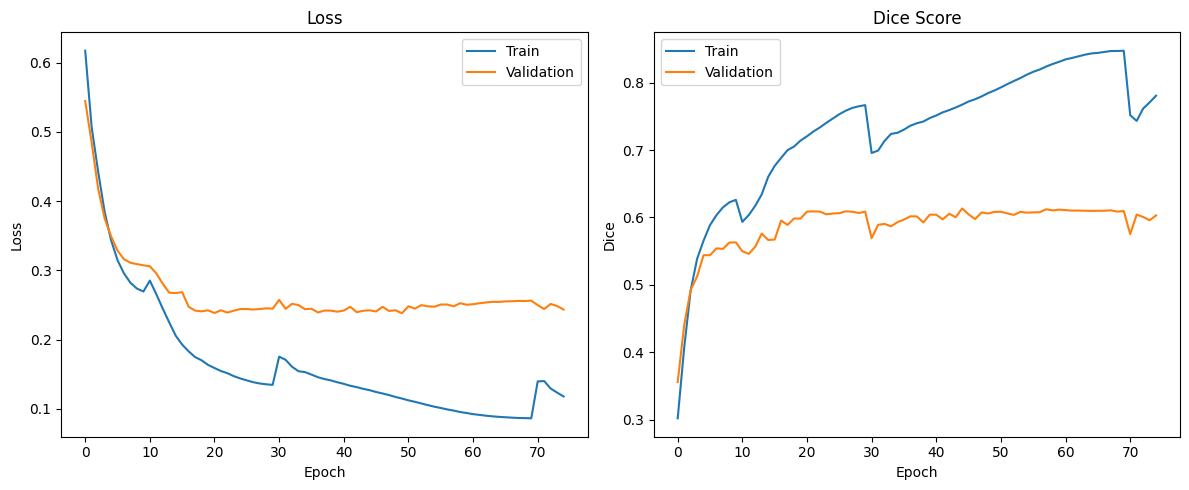

In [46]:
# ============================================================
# Training Curves
# ============================================================

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.plot(history["train_loss"], label="Train")
plt.plot(history["val_loss"], label="Validation")

plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1,2,2)

plt.plot(history["train_dice"], label="Train")
plt.plot(history["val_dice"], label="Validation")

plt.title("Dice Score")
plt.xlabel("Epoch")
plt.ylabel("Dice")
plt.legend()

plt.tight_layout()
plt.show()

In [47]:
# ============================================================
# Class Mask to RGB
# ============================================================

def classmask_to_rgb(mask):

    rgb = np.zeros(
        (mask.shape[0], mask.shape[1], 3),
        dtype=np.uint8
    )

    rgb[mask == 0] = [0, 0, 0]         # Background
    rgb[mask == 1] = [255, 0, 0]       # Artery
    rgb[mask == 2] = [0, 255, 0]       # Overlap
    rgb[mask == 3] = [0, 0, 255]       # Vein

    return rgb

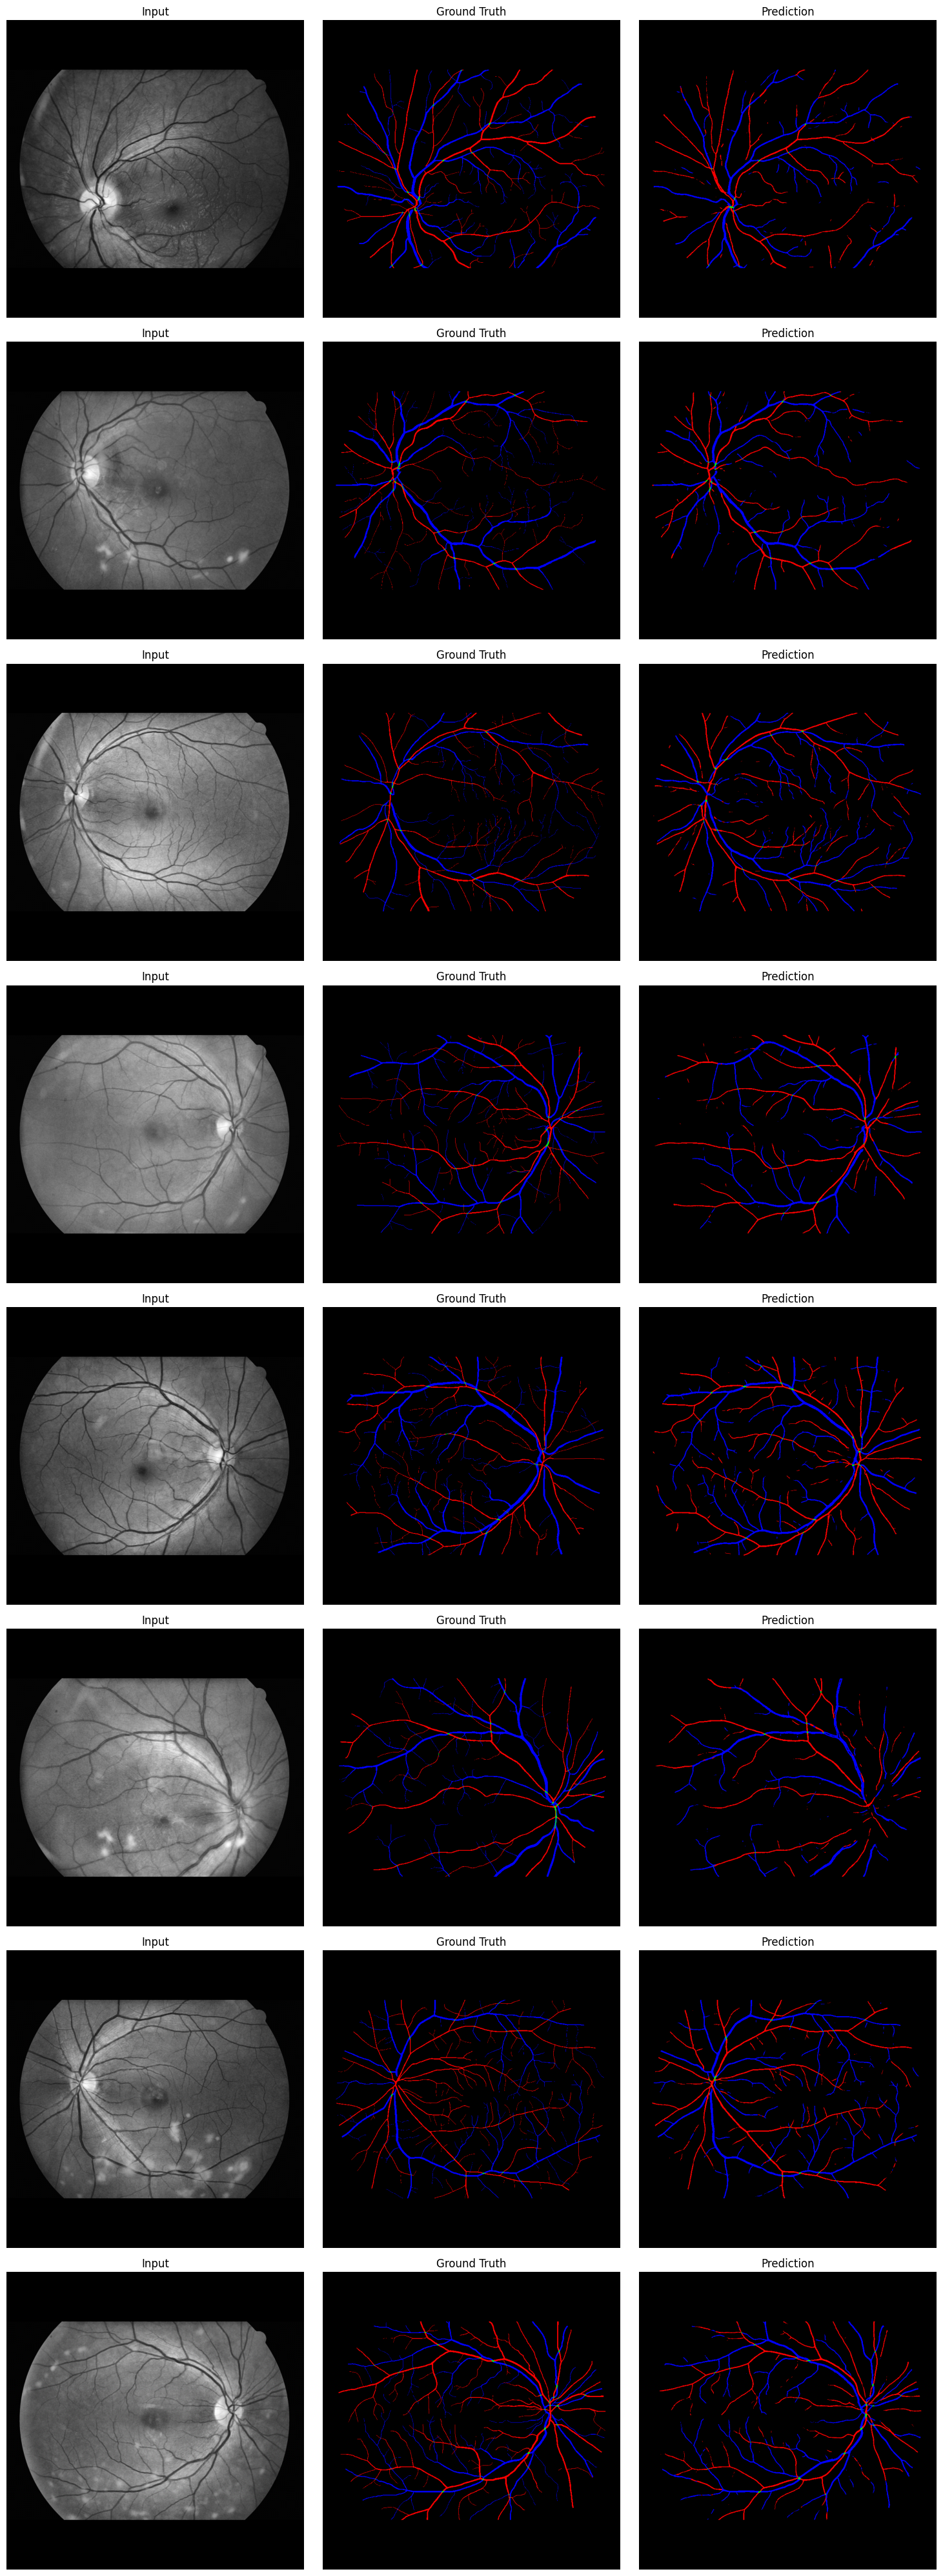

In [49]:
# ============================================================
# Visualization
# ============================================================

num_examples = 8

indices = np.random.choice(
    len(test_dataset),
    num_examples,
    replace=False
)

plt.figure(figsize=(15, 5 * num_examples))

for row, idx in enumerate(indices):

    image, gt , distance= test_dataset[idx]

    with torch.no_grad():

        output = model(
            image.unsqueeze(0).to(DEVICE)
        )

    pred = torch.argmax(
        output,
        dim=1
    ).squeeze().cpu().numpy()

    gt = gt.numpy()

    pred_rgb = classmask_to_rgb(pred)

    gt_rgb = classmask_to_rgb(gt)

    image = image.squeeze().numpy()

    plt.subplot(num_examples, 3, row * 3 + 1)
    plt.imshow(image, cmap="gray")
    plt.title("Input")
    plt.axis("off")

    plt.subplot(num_examples, 3, row * 3 + 2)
    plt.imshow(gt_rgb)
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(num_examples, 3, row * 3 + 3)
    plt.imshow(pred_rgb)
    plt.title("Prediction")
    plt.axis("off")

plt.tight_layout()

plt.show()